# 2次元三角形１次要素のプログラム

==============  Dマトリクス ========================
[[282692.30769231 121153.84615385      0.        ]
 [121153.84615385 282692.30769231      0.        ]
 [     0.              0.          80769.23076923]]
area_elements : 0.5
area_elements : 0.5
area_elements : 0.5
area_elements : 0.5
============== 要素剛性マトリクス ========================
========================== 要素0番目の剛性行列====================================
Ke[0] = 
[[-1.  0.  1.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  1.]
 [ 0. -1. -1.  1.  1.  0.]]
[[ 141346.15384615       0.         -141346.15384615   60576.92307692
        0.          -60576.92307692]
 [      0.           40384.61538462   40384.61538462  -40384.61538462
   -40384.61538462       0.        ]
 [-141346.15384615   40384.61538462  181730.76923077 -100961.53846154
   -40384.61538462   60576.92307692]
 [  60576.92307692  -40384.61538462 -100961.53846154  181730.76923077
    40384.61538462 -141346.15384615]
 [      0.          -40384.61538462  -40384.61538462   40384.61538462
    4

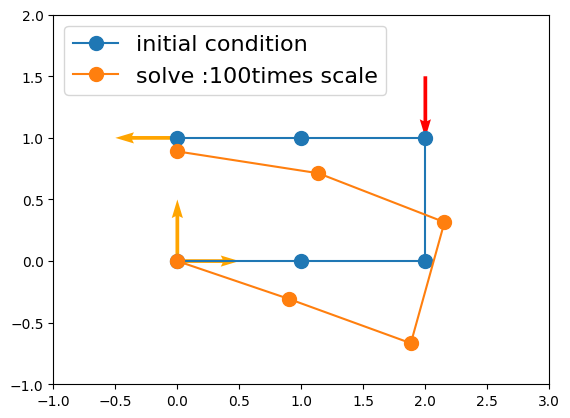

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 変数の定義
NODES = 6
ELEMENTS = 4
COMPONENTS = 3
NODE_TRIA3 = 3
DOF_NODE = 2
DOF_TOTAL = DOF_NODE * NODES
DOF_TRIA3 = DOF_NODE * NODE_TRIA3
THICKNESS = 1.0
YONG = 210000
POISSON = 0.3

# 初期状態
def initialize():
    x = np.zeros(NODES)
    y = np.zeros(NODES)
    #初期状態
    connectivity = np.zeros((ELEMENTS, NODE_TRIA3),dtype='int64')  
    # 要素内節点の順番
    connectivity[0,0] = 0 #0番の要素の0番目の節点のID
    connectivity[0,1] = 1 #0番の要素の1番目の節点のID
    connectivity[0,2] = 4 #0番の要素の2番目の節点のID

    connectivity[1,0] = 1 #1番の要素の0番目の節点のID 
    connectivity[1,1] = 2 #1番の要素の1番目の節点のID
    connectivity[1,2] = 3 #1番の要素の2番目の節点のID

    connectivity[2,0] = 1
    connectivity[2,1] = 3
    connectivity[2,2] = 4

    connectivity[3,0] = 0
    connectivity[3,1] = 4
    connectivity[3,2] = 5
    
    #IDに対する座標値
    x[0] = 0
    y[0] = 0

    x[1] = 1
    y[1] = 0

    x[2] = 2
    y[2] = 0

    x[3] = 2
    y[3] = 1

    x[4] = 1
    y[4] = 1

    x[5] = 0
    y[5] = 1
    
    return x, y, connectivity


# Dマトリクス
def make_D(YONG, POISSON):
    coef = YONG/(1-2*POISSON) /(1+POISSON)
    D = np.zeros((3,3))
    D[0,0] = coef * (1-POISSON)
    D[0,1] = coef * POISSON
    D[0,2] = coef * 0

    D[1,0] = coef * POISSON
    D[1,1] = coef * (1-POISSON)
    D[1,2] = coef * 0

    D[2,0] = D[0,2]
    D[2,1] = D[1,2]
    D[2,2] = coef * (1 - 2*POISSON)/2
    
    print("==============  Dマトリクス ========================")
    print(D)
    return D
    
# Bマトリクス
def make_B(x, y, connectivity):
    B= np.zeros((ELEMENTS, NODE_TRIA3,NODES))  
    area_elements= np.zeros(ELEMENTS)  # 要素ごとの面積

    for e in range(ELEMENTS):
        x0, y0 = x[connectivity[e,0]], y[connectivity[e,0]]
        x1, y1 = x[connectivity[e,1]], y[connectivity[e,1]]
        x2, y2 = x[connectivity[e,2]], y[connectivity[e,2]]
        # print(f"======= 要素{e}番目==========")
        # print(f"x0:{x0}, y0:{y0}")
        # print(f"x1:{x1}, y1:{y1}")
        # print(f"x2:{x2}, y2:{y2}")

        # 要素面積の計算
        area_elements[e] = (x0*y1-x0*y2+x1*y2-x1*y0+x2*y0-x2*y1)/2
        print(f"area_elements : {area_elements[e]}")

        coef = 1/area_elements[e]/2

        # 要素e番目の行列
        B[e,0,0] = coef *(y1-y2)
        B[e,0,1] = 0
        B[e,0,2] = coef *(y2-y0)
        B[e,0,3] = 0
        B[e,0,4] = coef *(y0-y1)
        B[e,0,5] = 0

        B[e,1,0] = 0
        B[e,1,1] = coef *(x2-x1)
        B[e,1,2] = 0
        B[e,1,3] = coef *(x0-x2)
        B[e,1,4] = 0
        B[e,1,5] = coef *(x1-x0)

        B[e,2,0] = B[e,1,1]
        B[e,2,1] = B[e,0,0]
        B[e,2,2] = B[e,1,3]
        B[e,2,3] = B[e,0,2]
        B[e,2,4] = B[e,1,5]
        B[e,2,5] = B[e,0,4]
        
    # print("==============  Bマトリクス ========================")
    # for e in range(ELEMENTS):
    #     print(f"======= 要素{e}番目==========")
    #     for n3 in range(NODE_TRIA3):
    #         print(f"       ======= 節点{n3}番目==========")
    #         for n in range(NODES):
    #             print(f"         B[{e},{n3},{n}] = {B[e,n3,n]}")
        
    return B, area_elements

def make_Ke(B, D, area_elements):
    '''
    NODES = 6
    ELEMENTS = 4
    COMPONENTS = 3 #ひずみと応力の成分数
    NODE_TRIA3 = 3
    DOF_NODE = 2
    DOF_TOTAL = DOF_NODE * NODES
    DOF_TRIA3 = DOF_NODE * NODE_TRIA3
    THICKNESS = 1.0
    '''
    Ke= np.zeros((ELEMENTS,  DOF_TRIA3, DOF_TRIA3) )  
    print("============== 要素剛性マトリクス ========================")
    for e in range(ELEMENTS):
        print(f"========================== 要素{e}番目の剛性行列====================================")
        print(f"Ke[{e}] = ")
        print(B[e])
        Ke[e] = THICKNESS*area_elements[e]*B[e].T @ D.T@ B[e]
        print(Ke[e])
    
    return Ke

# 全体剛性マトリクス
def make_K(connectivity, Ke):
    K= np.zeros((DOF_TOTAL, DOF_TOTAL) ) # 再度初期化しておく

    '''
        # 要素内節点の順番
        connectivity[0,0] = 0 #0番の要素の0番目の節点のID
        connectivity[0,1] = 1 #0番の要素の1番目の節点のID
        connectivity[0,2] = 4 #0番の要素の2番目の節点のID

        connectivity[1,0] = 1 #1番の要素の0番目の節点のID 
        connectivity[1,1] = 2 #1番の要素の1番目の節点のID
        connectivity[1,2] = 3 #1番の要素の2番目の節点のID

        connectivity[2,0] = 1
        connectivity[2,1] = 3
        connectivity[2,2] = 4

        connectivity[3,0] = 0
        connectivity[3,1] = 4
        connectivity[3,2] = 5
    '''
    for e in range(ELEMENTS):
        for r in range(DOF_TRIA3):
            #print("aaa ; ",e, (r+2) // DOF_NODE-1,connectivity[e, (r+2) // DOF_NODE-1])
            rt = connectivity[e, (r+2) // DOF_NODE-1] * DOF_NODE-( (r+1) % DOF_NODE) + 1
            #print("rt : ",rt)
            for c in range(DOF_TRIA3):
                #print("bbb ; ",e, (c+2) // DOF_NODE-1)
                ct = connectivity[e, (c+2)// DOF_NODE-1] * DOF_NODE-((c+1) % DOF_NODE) + 1
                #print("ct : ",ct)
                K[rt,ct] = K[rt,ct] + Ke[e,r,c]
    
    print("============= 全体剛性マトリクス K ====================")
    print(K)
    
    return K

def set_baoudary_U_F():
    # 全体変位ベクトル
    U = np.zeros(DOF_TOTAL)

    # 全体荷重ベクトル
    F = np.zeros(DOF_TOTAL)
    F[7] = -100.0
    
    print("============= 境界条件 ====================")
    print(f"U = {U}")
    print(f"F = {F}")
    
    return U, F
    
def solve_Ua(K, U, F):
    # 変位拘束のフラグを立てる
    Um = []
    for i in range(DOF_TOTAL):
        if i==0 or i==1 or i==10:
            Um.append(True)
        else:
            Um.append(False)
    Um = np.array(Um)

    # 剛性マトリクスとコピー
    Kc = K.copy()


    for r in range(DOF_TOTAL):
        if Um[r] == True:
            for rr in range(DOF_TOTAL): # 変位拘束が存在する行の成分を0にする
                if rr != r:
                    F[rr] -= Kc[rr,r]*U[r]
            for rr in range(DOF_TOTAL):
                Kc[rr,r] = 0.0

            for cc in range(DOF_TOTAL): # 変位拘束が存在する列の成分を0にする
                Kc[r, cc] = 0.0

            Kc[r,r] = 1.0 #対角成分を1
            F[r] = U[r]

    # 変位を計算
    Ua = np.linalg.inv(Kc) @ F
    
    print("============= 変位Ua ====================")
    print(f"Ua = {Ua}")
   
    return Ua

def make_position(Ua, x, y, scale): #変位は値が小さいのでスケールをかける
    xa = []
    ya = []
    
    for i in range(len(x)):
        xa.append(x[i] + scale*Ua[i*2])
        ya.append(y[i] + scale*Ua[i*2+1])
    
    import matplotlib.pyplot as plt

    plt.xlim(-1,3)
    plt.ylim(-1,2)
    plt.plot(x,y,marker='.',markersize=20, label="initial condition")
    plt.plot(xa,ya,marker='.',markersize=20, label=f"solve :{scale}times scale")

    
    return xa, ya

# 節点反力の計算
def make_reaction(K, Ua):
    Fr = K@Ua
    print("============= 節点反力 ====================")
    print(f"Fr = {Fr}")

    fsx, fsy = 2, 1.5
    ffx, ffy = 0, -1

    plt.quiver(fsx, fsy, ffx, ffy, color='red', angles='xy', scale_units='xy', scale=2)
    plt.quiver(0, 0, 1, 0, color='orange', angles='xy', scale_units='xy', scale=2)
    plt.quiver(0, 0, 0, 1, color='orange', angles='xy', scale_units='xy', scale=2)
    plt.quiver(0, 1, -1, 0, color='orange', angles='xy', scale_units='xy', scale=2)

    plt.legend(fontsize=16, loc="upper left")
    
    return Fr

# 要素ひずみの計算
def make_strain_element(B, Ua):
    Ue = np.zeros((DOF_TRIA3)) #各要素の変位
    strain_element = np.zeros((ELEMENTS, COMPONENTS))

    for e in range(ELEMENTS):
        for n in range(NODE_TRIA3):
            Ue[2*n] = Ua[connectivity[e,n]*2] # Uの偶数がx成分
            Ue[2*n+1] = Ua[connectivity[e,n]*2+1] # Uの偶数がx成分

        for r in range(COMPONENTS):
            strain_element[e] = B[e] @ Ue
    
    print("============= 要素ひずみの計算 ====================")
    for e in range(ELEMENTS):
        print(f"    ======= 要素{e}番目 εx, εy, γxy==========")
        print(strain_element[e])
    
    return strain_element

# 要素応力の計算
def make_stress_element(D, strain_element):
    Fe = np.zeros((ELEMENTS, COMPONENTS))

    for e in range(ELEMENTS):
            Fe[e] = D @ strain_element[e]
    
    print("============= 要素応力の計算 ====================")
    for e in range(ELEMENTS):
        print(f"      ======= 要素{e}番目  σx, σy, τxy==========")
        print(Fe[e])
    
    return Fe

if __name__ == "__main__":
    x, y, connectivity=  initialize()
    D = make_D(YONG, POISSON)
    B, area_elements = make_B(x, y, connectivity)
    Ke = make_Ke(B, D, area_elements)
    K = make_K(connectivity, Ke)
    U, F = set_baoudary_U_F()
    Ua = solve_Ua(K, U, F)
    xa, yb = make_position(Ua, x, y, 100)
    Fr = make_reaction(K, Ua)
    strain_element = make_strain_element(B, Ua)
    Fe = make_stress_element(D, strain_element)

このプログラムを３次元に拡張する

# Dataの読み込み

TEST_Tria3.xlsmにCATIAで作成したメッシュデータを入力しておく。

Pythonでエクセルに記載したNODEとELEMENT情報を読み込む。
<img src="img/3次元四面体１次要素メッシュNODE_ELEMENT.PNG">

In [2]:
'''
def initialize():
    x = np.zeros(NODES)
    y = np.zeros(NODES)
    #初期状態
    connectivity = np.zeros((ELEMENTS, NODE_TRIA3),dtype='int64')  
    # 要素内節点の順番
    connectivity[0,0] = 0 #0番の要素の0番目の節点のID
    connectivity[0,1] = 1 #0番の要素の1番目の節点のID
    connectivity[0,2] = 4 #0番の要素の2番目の節点のID

    connectivity[1,0] = 1 #1番の要素の0番目の節点のID 
    connectivity[1,1] = 2 #1番の要素の1番目の節点のID
    connectivity[1,2] = 3 #1番の要素の2番目の節点のID

    connectivity[2,0] = 1
    connectivity[2,1] = 3
    connectivity[2,2] = 4

    connectivity[3,0] = 0
    connectivity[3,1] = 4
    connectivity[3,2] = 5
    
    #IDに対する座標値
    x[0] = 0
    y[0] = 0

    x[1] = 1
    y[1] = 0

    x[2] = 2
    y[2] = 0

    x[3] = 2
    y[3] = 1

    x[4] = 1
    y[4] = 1

    x[5] = 0
    y[5] = 1
'''
import openpyxl
wb = openpyxl.load_workbook('TEST_Tria3.xlsm') #ワークブックの指定
ws = wb['節点要素情報'] ##シート名を指定して取得
ws

<Worksheet "節点要素情報">

node座標を読み込む

In [3]:
node_ids = [] 
for row in range(3,ws.max_row):
    if ws.cell(row=row, column=1).value == None: break
    node_ids.append(ws.cell(row=row, column=1).value)

In [4]:
NODES = len(node_ids) # NODE数
x = np.zeros(NODES) 
y = np.zeros(NODES)
z = np.zeros(NODES)

In [5]:
# x,y 座標の読み込み
for n in range(len(node_ids)):
    x[n] = ws.cell(row=3+n, column=2).value
    y[n] = ws.cell(row=3+n, column=3).value
    z[n] = ws.cell(row=3+n, column=4).value

## 確認

In [6]:
Node_data = {}
Node_data = {
    "nodeID":node_ids,
    "x":x,
    "y":y,
    "z":z
}
import pandas as pd
df_node = pd.DataFrame(Node_data)
df_node

,nodeID,x,y,z
0,1,2.000000,0.000000,0.000000
1,2,2.000000,0.000000,2.000000
2,3,2.000000,10.000000,0.000000
3,4,2.000000,10.000000,2.000000
4,5,0.000000,10.000000,0.000000
...,...,...,...,...
95,96,0.978207,1.839272,0.971997
96,97,0.407052,7.599849,1.309741
97,98,1.421541,1.728902,1.467327
98,99,1.454454,8.393606,1.464986


In [7]:
df_node["nodeID"] = df_node["nodeID"]-1

In [8]:
df_node

,nodeID,x,y,z
0,0,2.000000,0.000000,0.000000
1,1,2.000000,0.000000,2.000000
2,2,2.000000,10.000000,0.000000
3,3,2.000000,10.000000,2.000000
4,4,0.000000,10.000000,0.000000
...,...,...,...,...
95,95,0.978207,1.839272,0.971997
96,96,0.407052,7.599849,1.309741
97,97,1.421541,1.728902,1.467327
98,98,1.454454,8.393606,1.464986


ELEMENTを読み込む

In [9]:
element_ids = [] 

for row in range(3,ws.max_row):
    if ws.cell(row=row, column=6).value == None: break
    element_ids.append(ws.cell(row=row, column=6).value)

ELEMENTS = len(element_ids) # NODE数
n1 = np.zeros(ELEMENTS) 
n2 = np.zeros(ELEMENTS)
n3 = np.zeros(ELEMENTS)
n4 = np.zeros(ELEMENTS)

for e in range(len(element_ids)):
    n1[e] = int(ws.cell(row=3+e, column=7).value)
    n2[e] = int(ws.cell(row=3+e, column=8).value)
    n3[e] = int(ws.cell(row=3+e, column=9).value)
    n4[e] = int(ws.cell(row=3+e, column=10).value)

In [10]:
Element_data = {}
Element_data = {
    "elementID":element_ids,
    "n1":n1,
    "n2":n2,
    "n3":n3,
    "n4":n4
}
import pandas as pd
df_element = pd.DataFrame(Element_data)
df_element

,elementID,n1,n2,n3,n4
0,1,68.0,69.0,91.0,92.0
1,2,57.0,14.0,58.0,93.0
2,3,58.0,59.0,26.0,94.0
3,4,64.0,95.0,88.0,96.0
4,5,55.0,56.0,91.0,92.0
...,...,...,...,...,...
247,248,70.0,50.0,49.0,100.0
248,249,15.0,77.0,78.0,93.0
249,250,66.0,86.0,45.0,87.0
250,251,57.0,77.0,14.0,93.0


In [11]:
df_element.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   elementID  252 non-null    int64  
 1   n1         252 non-null    float64
 2   n2         252 non-null    float64
 3   n3         252 non-null    float64
 4   n4         252 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 10.0 KB


In [12]:
df_element.columns

Index(['elementID', 'n1', 'n2', 'n3', 'n4'], dtype='object')

In [13]:
for e in df_element.columns:
    df_element[e] = df_element[e]-1
    df_element[e] = df_element[e].astype(int)

In [14]:
df_node

,nodeID,x,y,z
0,0,2.000000,0.000000,0.000000
1,1,2.000000,0.000000,2.000000
2,2,2.000000,10.000000,0.000000
3,3,2.000000,10.000000,2.000000
4,4,0.000000,10.000000,0.000000
...,...,...,...,...
95,95,0.978207,1.839272,0.971997
96,96,0.407052,7.599849,1.309741
97,97,1.421541,1.728902,1.467327
98,98,1.454454,8.393606,1.464986


In [15]:
df_element

,elementID,n1,n2,n3,n4
0,0,67,68,90,91
1,1,56,13,57,92
2,2,57,58,25,93
3,3,63,94,87,95
4,4,54,55,90,91
...,...,...,...,...,...
247,247,69,49,48,99
248,248,14,76,77,92
249,249,65,85,44,86
250,250,56,76,13,92


# 変数の定義

In [16]:
# 変数の定義
NODES = NODES
ELEMENTS = ELEMENTS
COMPONENTS = 6
NODE_TRIA4 = 4
DOF_NODE = 3
DOF_TOTAL = DOF_NODE * NODES
DOF_TRIA4 = DOF_NODE * NODE_TRIA4
YONG = 210000
POISSON = 0.3

# 初期状態
x = df_node["x"]
y = df_node["y"]
z = df_node["z"]
connectivity = np.zeros((ELEMENTS, NODE_TRIA4),dtype='int64')  

In [17]:
'''
    # 要素内節点の順番
    connectivity[0,0] = 0 #0番の要素の0番目の節点のID
    connectivity[0,1] = 1 #0番の要素の1番目の節点のID
    connectivity[0,2] = 4 #0番の要素の2番目の節点のID

    connectivity[1,0] = 1 #1番の要素の0番目の節点のID 
    connectivity[1,1] = 2 #1番の要素の1番目の節点のID
    connectivity[1,2] = 3 #1番の要素の2番目の節点のID
'''

for e in range(ELEMENTS):
    connectivity[df_element["elementID"].iloc[e],0] = df_element["n1"].iloc[e] #e番の要素の1番目の節点のID
    connectivity[df_element["elementID"].iloc[e],1] = df_element["n2"].iloc[e] #e番の要素の1番目の節点のID
    connectivity[df_element["elementID"].iloc[e],2] = df_element["n3"].iloc[e] #e番の要素の1番目の節点のID
    connectivity[df_element["elementID"].iloc[e],3] = df_element["n4"].iloc[e] #e番の要素の1番目の節点のID

for e in range(ELEMENTS):
    print(f"======= {e}番目の要素 =================")
    print(connectivity[e])
    if e == 10: break

======= 0番目の要素 =================
[67 68 90 91]
======= 1番目の要素 =================
[56 13 57 92]
======= 2番目の要素 =================
[57 58 25 93]
======= 3番目の要素 =================
[63 94 87 95]
======= 4番目の要素 =================
[54 55 90 91]
======= 5番目の要素 =================
[68 96 90 91]
======= 6番目の要素 =================
[59 60 97 95]
======= 7番目の要素 =================
[57 77 65 92]
======= 8番目の要素 =================
[19 20 82 98]
======= 9番目の要素 =================
[46 83 84 90]
======= 10番目の要素 =================
[53 82 98 99]


# D行列

D行列はひずみと応力を結びつける構成式$\{\sigma\}=[D]\{\varepsilon\}$

3次元のD行列は、
$$
D=\frac{E}{(1+\nu)(1-2\nu)}\begin{Bmatrix}
   1-\nu & \nu & \nu & 0 & 0 & 0 \\
   \nu & 1-\nu & \nu & 0 & 0 & 0 \\
   \nu & \nu & 1-\nu & 0 & 0 & 0 \\
   0 & 0 & 0 & \frac{1-2\nu}{2} & 0 & 0\\ 
   0 & 0 & 0 & 0 & \frac{1-2\nu}{2} & 0\\ 
   0 & 0 & 0 & 0 & 0 & \frac{1-2\nu}{2}\\ 
\end{Bmatrix}
$$


In [18]:
np.set_printoptions(linewidth=300)

In [19]:
# Dマトリクス
coef = YONG/(1-2*POISSON) /(1+POISSON)
D = np.zeros((6,6))
D[0,0] = coef * (1-POISSON)
D[0,1] = coef * POISSON
D[0,2] = coef * POISSON
D[0,3] = coef * 0
D[0,4] = coef * 0
D[0,5] = coef * 0

D[1,0] = coef * POISSON
D[1,1] = coef * (1-POISSON)
D[1,2] = coef * POISSON
D[1,3] = coef * 0
D[1,4] = coef * 0
D[1,5] = coef * 0

D[2,0] = coef * POISSON
D[2,1] = coef * POISSON
D[2,2] = coef * (1-POISSON)
D[2,3] = coef * 0
D[2,4] = coef * 0
D[2,5] = coef * 0

D[3,0] = coef * 0
D[3,1] = coef * 0
D[3,2] = coef * 0
D[3,3] = coef * (1 - 2*POISSON)/2
D[3,4] = coef * 0
D[3,5] = coef * 0

D[4,0] = coef * 0
D[4,1] = coef * 0
D[4,2] = coef * 0
D[4,3] = coef * 0
D[4,4] = coef * (1 - 2*POISSON)/2
D[4,5] = coef * 0

D[5,0] = coef * 0
D[5,1] = coef * 0
D[5,2] = coef * 0
D[5,3] = coef * 0
D[5,4] = coef * 0
D[5,5] = coef * (1 - 2*POISSON)/2

print("==============  Dマトリクス ========================")
print(D)

==============  Dマトリクス ========================
[[282692.30769231 121153.84615385 121153.84615385      0.              0.              0.        ]
 [121153.84615385 282692.30769231 121153.84615385      0.              0.              0.        ]
 [121153.84615385 121153.84615385 282692.30769231      0.              0.              0.        ]
 [     0.              0.              0.          80769.23076923      0.              0.        ]
 [     0.              0.              0.              0.          80769.23076923      0.        ]
 [     0.              0.              0.              0.              0.          80769.23076923]]


# B行列

## 変位

座標から変位を補間する。

$$
\left\{\begin{matrix}
u=\alpha_{1}+\alpha_{2}x+\alpha_{3}y+\alpha_{4}z\\
v=\beta_{1}+\beta_{2}x+\beta_{3}y+\beta_{4}z\\
w=\gamma_{1}+\gamma_{2}x+\gamma_{3}y+\gamma_{4}z\\
\end{matrix}\right.
$$

各点G1, G2, G3, G4を通るので以下を得る。

### G1

$
\left\{\begin{matrix}
u_{1}=\alpha_{1}+\alpha_{2}x_{1}+\alpha_{3}y_{1}+\alpha_{4}z_{1}\\
v_{1}=\beta_{1}+\beta_{2}x_{1}+\beta_{3}y_{1}+\beta_{4}z_{1}\\
w_{1}=\gamma_{1}+\gamma_{2}x_{1}+\gamma_{3}y_{1}+\gamma_{4}z_{1}\\
\end{matrix}\right.
$

### G2

$
\left\{\begin{matrix}
u_{2}=\alpha_{1}+\alpha_{2}x_{2}+\alpha_{3}y_{2}+\alpha_{4}z_{2}\\
v_{2}=\beta_{1}+\beta_{2}x_{2}+\beta_{3}y_{2}+\beta_{4}z_{2}\\
w_{2}=\gamma_{1}+\gamma_{2}x_{2}+\gamma_{3}y_{2}+\gamma_{4}z_{2}\\
\end{matrix}\right.
$

### G3

$
\left\{\begin{matrix}
u_{3}=\alpha_{1}+\alpha_{2}x_{3}+\alpha_{3}y_{3}+\alpha_{4}z_{3}\\
v_{3}=\beta_{1}+\beta_{2}x_{3}+\beta_{3}y_{3}+\beta_{4}z_{3}\\
w_{3}=\gamma_{1}+\gamma_{2}x_{3}+\gamma_{3}y_{2}+\gamma_{4}z_{3}\\
\end{matrix}\right.
$

### G4

$
\left\{\begin{matrix}
u_{4}=\alpha_{1}+\alpha_{2}x_{4}+\alpha_{3}y_{4}+\alpha_{4}z_{4}\\
v_{4}=\beta_{1}+\beta_{2}x_{4}+\beta_{3}y_{4}+\beta_{4}z_{4}\\
w_{4}=\gamma_{1}+\gamma_{2}x_{4}+\gamma_{3}y_{4}+\gamma_{4}z_{4}\\
\end{matrix}\right.
$

まずは、以下を求めることを考える。

- $\alpha_{1}, \alpha_{2}, \alpha_{3}, , \alpha_{4}$
- $\beta_{1}, \beta_{2}, \beta_{3}, , \beta_{4}$
- $\gamma_{1}, \gamma_{2}, \gamma_{3}, , \gamma_{4}$

$$
\begin{Bmatrix}
   u{1} \\
   u{2} \\
   u{3} 
\end{Bmatrix}
=\begin{bmatrix}
   x_{1} & y_{1} &  1\\
   x_{2} & y_{2} &  1\\
   x_{3} & y_{3} &  1\\
\end{bmatrix}
\begin{Bmatrix}
   a \\
   b \\
   c 
\end{Bmatrix}
$$

$$
\begin{Bmatrix}
   v{1} \\
   v{2} \\
   v{3} 
\end{Bmatrix}
=\begin{bmatrix}
   x_{1} & y_{1} &  1\\
   x_{2} & y_{2} &  1\\
   x_{3} & y_{3} &  1\\
\end{bmatrix}
\begin{Bmatrix}
   a^{\prime} \\
   b^{\prime} \\
   c^{\prime} 
\end{Bmatrix}
$$

$a,b,c,a^{\prime},b^{\prime},c^{\prime}$を求める。

三角形要素の面積$\Delta$として$2\Delta = x_{1}y_{2}+x_{2}y_{3}+x_{3}y_{1}-x_{1}y_{3}-x_{2}y_{1}-x_{3}y_{2}$

三角形１次要素の以下の形状関数が求まる。

- $N_{1}(x,y)=\frac{1}{2\Delta}\big((y_{2}-y_{3})+(x_{3}-x_{2})+(x_{2}y_{3}-x_{3}y_{2})\big)$
- $N_{2}(x,y)=\frac{1}{2\Delta}\big((y_{3}-y_{1})+(x_{1}-x_{3})+(x_{3}y_{1}-x_{1}y_{3})\big)$
- $N_{3}(x,y)=\frac{1}{2\Delta}\big((y_{1}-y_{2})+(x_{2}-x_{1})+(x_{1}y_{2}-x_{2}y_{1})\big)$

形状関数$N_{1}(x,y),N_{2}(x,y),N_{3}(x,y)$を使って、

- $u=N_{1}u_{1}+N_{2}u_{2}+N_{3}u_{3}$
- $v=N_{1}v_{1}+N_{2}v_{2}+N_{3}v_{3}$

行列を表記をして、

$$
\begin{Bmatrix}
   u_{1} \\
   u_{2} \\
   u_{3} \\
   u_{4} 
\end{Bmatrix}=
\underset{[A]^{-1}}{\begin{bmatrix}
1 & x_{1}& y_{1} & z_{1} \\
1 & x_{2}& y_{2} & z_{2} \\
1 & x_{3}& y_{3} & z_{3} \\
1 & x_{4}& y_{4} & z_{4} \\
\end{bmatrix}}
\begin{Bmatrix}
   \alpha_{1} \\
   \alpha_{2} \\
   \alpha_{3} \\
   \alpha_{4} 
\end{Bmatrix}
$$

$$
\begin{Bmatrix}
   v_{1} \\
   v_{2} \\
   v_{3} \\
   v_{4} 
\end{Bmatrix}=
\underset{[A]^{-1}}{\begin{bmatrix}
1 & x_{1}& y_{1} & z_{1} \\
1 & x_{2}& y_{2} & z_{2} \\
1 & x_{3}& y_{3} & z_{3} \\
1 & x_{4}& y_{4} & z_{4} \\
\end{bmatrix}}
\begin{Bmatrix}
   \beta_{1} \\
   \beta_{2} \\
   \beta_{3} \\
   \beta_{4} 
\end{Bmatrix}
$$

$$
\begin{Bmatrix}
   w_{1} \\
   w_{2} \\
   w_{3} \\
   w_{4} 
\end{Bmatrix}=
\underset{[A]^{-1}}{\begin{bmatrix}
1 & x_{1}& y_{1} & z_{1} \\
1 & x_{2}& y_{2} & z_{2} \\
1 & x_{3}& y_{3} & z_{3} \\
1 & x_{4}& y_{4} & z_{4} \\
\end{bmatrix}}
\begin{Bmatrix}
   \gamma_{1} \\
   \gamma_{2} \\
   \gamma_{3} \\
   \gamma_{4} 
\end{Bmatrix}
$$

※$[A]$の逆行列が存在するとしている。

$\{u\}=[A]^{-1}\{\alpha\}$の左から$A$を作用させて、$\{\alpha\}=[A]\{u\}$
$$
\begin{Bmatrix}
   \alpha_{1} \\
   \alpha_{2} \\
   \alpha_{3} \\
   \alpha_{4} 
\end{Bmatrix}=
\underset{[A]}{\begin{bmatrix}
1 & x_{1}& y_{1} & z_{1} \\
1 & x_{2}& y_{2} & z_{2} \\
1 & x_{3}& y_{3} & z_{3} \\
1 & x_{4}& y_{4} & z_{4} \\
\end{bmatrix}^{-1}}
\begin{Bmatrix}
   u_{1} \\
   u_{2} \\
   u_{3} \\
   u_{4} 
\end{Bmatrix}
$$

$$
\begin{Bmatrix}
   \beta_{1} \\
   \beta_{2} \\
   \beta_{3} \\
   \beta_{4} 
\end{Bmatrix}=
\underset{[A]}{\begin{bmatrix}
1 & x_{1}& y_{1} & z_{1} \\
1 & x_{2}& y_{2} & z_{2} \\
1 & x_{3}& y_{3} & z_{3} \\
1 & x_{4}& y_{4} & z_{4} \\
\end{bmatrix}^{-1}}
\begin{Bmatrix}
   v_{1} \\
   v_{2} \\
   v_{3} \\
   v_{4} 
\end{Bmatrix}
$$

$$
\begin{Bmatrix}
   \gamma_{1} \\
   \gamma_{2} \\
   \gamma_{3} \\
   \gamma_{4} 
\end{Bmatrix}=
\underset{[A]}{\begin{bmatrix}
1 & x_{1}& y_{1} & z_{1} \\
1 & x_{2}& y_{2} & z_{2} \\
1 & x_{3}& y_{3} & z_{3} \\
1 & x_{4}& y_{4} & z_{4} \\
\end{bmatrix}^{-1}}
\begin{Bmatrix}
   w_{1} \\
   w_{2} \\
   w_{3} \\
   w_{4} 
\end{Bmatrix}
$$

ここで、

$$
\begin{bmatrix}
1 & x_{1}& y_{1} & z_{1} \\
1 & x_{2}& y_{2} & z_{2} \\
1 & x_{3}& y_{3} & z_{3} \\
1 & x_{4}& y_{4} & z_{4} \\
\end{bmatrix}^{-1}=
\frac{1}{6V}
\begin{bmatrix}
a_{1} & a_{2}& a_{3} & a_{4} \\
b_{1} & b_{2}& b_{3} & b_{4} \\
c_{1} & c_{2}& c_{3} & c_{4} \\
d_{1} & d_{2}& d_{3} & d_{4} \\
\end{bmatrix}
$$

$a_{i},b_{i},c_{i},d_{i} (i=1,2,3,4)$は余因子展開で求めることができる。

余因子展開の手計算は大変だが、$\begin{bmatrix}
1 & x_{1}& y_{1} & z_{1} \\
1 & x_{2}& y_{2} & z_{2} \\
1 & x_{3}& y_{3} & z_{3} \\
1 & x_{4}& y_{4} & z_{4} \\
\end{bmatrix}^{-1}$の逆行列はPythonで簡単に計算できる。


$a,b,c,a^{\prime},b^{\prime},c^{\prime}$を求める。


四面体要素の体積$V=\frac{1}{6}\begin{vmatrix}
1 & x_{1}& y_{1} & z_{1} \\
1 & x_{2}& y_{2} & z_{2} \\
1 & x_{3}& y_{3} & z_{3} \\
1 & x_{4}& y_{4} & z_{4} \\
\end{vmatrix}$

四面体要素１次要素の以下の形状関数が求まる。

- $N_{1}(x,y,z)=a_{1}+b_{1}x+c_{1}y+d_{1}z$
- $N_{2}(x,y,z)=a_{2}+b_{2}x+c_{2}y+d_{2}z$
- $N_{3}(x,y,z)=a_{3}+b_{3}x+c_{3}y+d_{3}z$
- $N_{4}(x,y,z)=a_{4}+b_{4}x+c_{4}y+d_{4}z$


形状関数$N_{1}(x,y),N_{2}(x,y),N_{3}(x,y)$を使って、

- $u=N_{1}u_{1}+N_{2}u_{2}+N_{3}u_{3}+N_{4}u_{4}$
- $v=N_{1}v_{1}+N_{2}v_{2}+N_{3}v_{3}+N_{4}v_{4}$
- $w=N_{1}w_{1}+N_{2}w_{2}+N_{3}w_{3}+N_{4}w_{4}$


ひずみから変位を求める

$$\varepsilon = \frac{\partial \boldsymbol{u}}{\partial  \boldsymbol{x}}$$

$$
\begin{Bmatrix}
   \varepsilon_{x} \\
   \varepsilon_{y} \\
   \varepsilon_{y} \\   
   \gamma_{xy} \\
   \gamma_{yz} \\
   \gamma_{zx} 
\end{Bmatrix}=
\begin{Bmatrix}
   \frac{\partial u}{\partial x} \\
   \frac{\partial v}{\partial y} \\
   \frac{\partial w}{\partial z} \\
   \frac{\partial u}{\partial y} +\frac{\partial v}{\partial x} \\
   \frac{\partial v}{\partial z} +\frac{\partial w}{\partial y} \\
   \frac{\partial w}{\partial x} +\frac{\partial u}{\partial z} 
\end{Bmatrix}
=\begin{bmatrix}
\frac{\partial N_{1}}{\partial x} & 0 &0 &  \frac{\partial N_{2}}{\partial x} & 0 &0 & \frac{\partial N_{3}}{\partial x} & 0 &0 & \frac{\partial N_{4}}{\partial x} & 0 &0\\
0 & \frac{\partial N_{1}}{\partial y} & 0 & 0 &  \frac{\partial N_{2}}{\partial y} & 0 &0 & \frac{\partial N_{3}}{\partial y} &0 & 0&\frac{\partial N_{4}}{\partial y} &0\\
0 & 0 & \frac{\partial N_{1}}{\partial z} & 0 & 0 &  \frac{\partial N_{2}}{\partial z} & 0 &0 & \frac{\partial N_{3}}{\partial z} &0 &0 &\frac{\partial N_{4}}{\partial z}\\
\frac{\partial N_{1}}{\partial y} & \frac{\partial N_{1}}{\partial x} &  0 & \frac{\partial N_{2}}{\partial y} & \frac{\partial N_{2}}{\partial x} & 0 & \frac{\partial N_{3}}{\partial y} & \frac{\partial N_{3}}{\partial x} &0 & \frac{\partial N_{4}}{\partial y} & \frac{\partial N_{4}}{\partial x} &0\\
0 &\frac{\partial N_{1}}{\partial z} & \frac{\partial N_{1}}{\partial y} &  0 & \frac{\partial N_{2}}{\partial z} & \frac{\partial N_{2}}{\partial y} & 0 & \frac{\partial N_{3}}{\partial z} & \frac{\partial N_{3}}{\partial y} &0 & \frac{\partial N_{4}}{\partial z} & \frac{\partial N_{4}}{\partial y} \\
\frac{\partial N_{1}}{\partial z} & 0 &\frac{\partial N_{1}}{\partial x} & \frac{\partial N_{2}}{\partial z} & 0 & \frac{\partial N_{2}}{\partial x} &   \frac{\partial N_{3}}{\partial z} & 0 & \frac{\partial N_{3}}{\partial x} & \frac{\partial N_{4}}{\partial z} &0 &\frac{\partial N_{4}}{\partial x}\\
\end{bmatrix}
\begin{Bmatrix}
   u_{1} \\
   v_{1} \\
   w_{1} \\
   u_{2} \\
   v_{2} \\
   w_{2} \\
   u_{3} \\
   v_{3} \\
   w_{3} \\
   u_{4} \\
   v_{4} \\
   w_{4} \\
\end{Bmatrix}
$$

行列でまとめると$${\boldsymbol{\varepsilon}}=[B][\boldsymbol{u}]$$

となり、Bマトリクスのように定義できる。

$$
B=\begin{bmatrix}
\frac{\partial N_{1}}{\partial x} & 0 &0 &  \frac{\partial N_{2}}{\partial x} & 0 &0 & \frac{\partial N_{3}}{\partial x} & 0 &0 & \frac{\partial N_{4}}{\partial x} & 0 &0\\
0 & \frac{\partial N_{1}}{\partial y} & 0 & 0 &  \frac{\partial N_{2}}{\partial y} & 0 &0 & \frac{\partial N_{3}}{\partial y} &0 & 0&\frac{\partial N_{4}}{\partial y} &0\\
0 & 0 & \frac{\partial N_{1}}{\partial z} & 0 & 0 &  \frac{\partial N_{2}}{\partial z} & 0 &0 & \frac{\partial N_{3}}{\partial z} &0 &0 &\frac{\partial N_{4}}{\partial z}\\
\frac{\partial N_{1}}{\partial y} & \frac{\partial N_{1}}{\partial x} &  0 & \frac{\partial N_{2}}{\partial y} & \frac{\partial N_{2}}{\partial x} & 0 & \frac{\partial N_{3}}{\partial y} & \frac{\partial N_{3}}{\partial x} &0 & \frac{\partial N_{4}}{\partial y} & \frac{\partial N_{4}}{\partial x} &0\\
0 &\frac{\partial N_{1}}{\partial z} & \frac{\partial N_{1}}{\partial y} &  0 & \frac{\partial N_{2}}{\partial z} & \frac{\partial N_{2}}{\partial y} & 0 & \frac{\partial N_{3}}{\partial z} & \frac{\partial N_{3}}{\partial y} &0 & \frac{\partial N_{4}}{\partial z} & \frac{\partial N_{4}}{\partial y} \\
\frac{\partial N_{1}}{\partial z} & 0 &\frac{\partial N_{1}}{\partial x} & \frac{\partial N_{2}}{\partial z} & 0 & \frac{\partial N_{2}}{\partial x} &   \frac{\partial N_{3}}{\partial z} & 0 & \frac{\partial N_{3}}{\partial x} & \frac{\partial N_{4}}{\partial z} &0 &\frac{\partial N_{4}}{\partial x}\\
\end{bmatrix}
$$

以上のように変位からひずみが計算される。

具体的に書くと、
$$
B=\begin{bmatrix}
b_{1} & 0 &0 & b_{2} & 0 &0 & b_{3} & 0 &0 & b_{4} & 0 &0\\
0 & c_{1} & 0 & 0 &  c_{2} & 0 &0 & c_{3} &0 & 0&c_{4} &0\\
0 & 0 & d_{1}& 0 & 0 &  d_{2} & 0 &0 & d_{3}&0 &0 &d_{4}\\
c_{1} & b_{1} &  0 & c_{2} & b_{2} & 0 & c_{3} & b_{3} &0 & c_{4} & b_{4}&0\\
0 & d_{1}& c_{1} &  0 & d_{2} & c_{2} & 0 & d_{3}& c_{3} &0 & d_{4} & c_{4}\\
d_{1} & 0 & b_{1} & d_{2} & 0 & b_{2} & d_{3} & 0 & b_{3}& d_{4} &0 &b_{4}\\
\end{bmatrix}
$$

各成分は$\begin{bmatrix}
1 & x_{1}& y_{1} & z_{1} \\
1 & x_{2}& y_{2} & z_{2} \\
1 & x_{3}& y_{3} & z_{3} \\
1 & x_{4}& y_{4} & z_{4} \\
\end{bmatrix}^{-1}=
\frac{1}{6V}
\begin{bmatrix}
a_{1} & a_{2}& a_{3} & a_{4} \\
b_{1} & b_{2}& b_{3} & b_{4} \\
c_{1} & c_{2}& c_{3} & c_{4} \\
d_{1} & d_{2}& d_{3} & d_{4} \\
\end{bmatrix}$の逆行列から求まる成分であることに注意（手計算で求めるのは少々困難）

プログラム上は$[A\_ ] =\begin{bmatrix}
a_{1} & a_{2}& a_{3} & a_{4} \\
b_{1} & b_{2}& b_{3} & b_{4} \\
c_{1} & c_{2}& c_{3} & c_{4} \\
d_{1} & d_{2}& d_{3} & d_{4} \\
\end{bmatrix}$と置くことにする。

プグラムでの求め方はPythonの```np.linalg.inv```を使って$\begin{bmatrix}
1 & x_{1}& y_{1} & z_{1} \\
1 & x_{2}& y_{2} & z_{2} \\
1 & x_{3}& y_{3} & z_{3} \\
1 & x_{4}& y_{4} & z_{4} \\
\end{bmatrix}^{-1}$の逆行列を計算し、$[A\_ ] =\begin{bmatrix}
a_{1} & a_{2}& a_{3} & a_{4} \\
b_{1} & b_{2}& b_{3} & b_{4} \\
c_{1} & c_{2}& c_{3} & c_{4} \\
d_{1} & d_{2}& d_{3} & d_{4} \\
\end{bmatrix}=6V\begin{bmatrix}
1 & x_{1}& y_{1} & z_{1} \\
1 & x_{2}& y_{2} & z_{2} \\
1 & x_{3}& y_{3} & z_{3} \\
1 & x_{4}& y_{4} & z_{4} \\
\end{bmatrix}^{-1}$より求める。

In [20]:
B= np.zeros((ELEMENTS,COMPONENTS, DOF_TRIA4))
volume_elements= np.zeros(ELEMENTS)  # 要素ごとの体積

for e in range(ELEMENTS):
    x0, y0, z0 = x[connectivity[e,0]], y[connectivity[e,0]], z[connectivity[e,0]]
    x1, y1, z1 = x[connectivity[e,1]], y[connectivity[e,1]], z[connectivity[e,1]]
    x2, y2, z2 = x[connectivity[e,2]], y[connectivity[e,2]], z[connectivity[e,2]]
    x3, y3, z3 = x[connectivity[e,3]], y[connectivity[e,3]], z[connectivity[e,3]]
    #print(f"======= 要素{e}番目==========")
    # print(f"x0:{x0}, y0:{y0}, z0:{z0}")
    # print(f"x1:{x1}, y1:{y1}, z1:{z1}")
    # print(f"x2:{x2}, y2:{y2}, z2:{z2}")
    # print(f"x3:{x3}, y3:{y3}, z3:{z3}")

    # 要素体積の計算(6*行列式で体積を計算）
    det_ = np.linalg.det(
                np.array([
                    [1, x0, y0, z0],
                    [1, x1, y1, z1],
                    [1, x2, y2, z2],
                    [1, x3, y3, z3]
                ]
        )
    )
    volume_elements[e] = 6*det_
    #print(f"{df_element['elementID'].iloc[e]} : volume_elements : {volume_elements[e]}")

    '''
       [1, x0, y0, z0],
       [1, x1, y1, z1],
       [1, x2, y2, z2],
       [1, x3, y3, z3]
       の逆行列
    '''
    A_ = 6*volume_elements[e]*np.linalg.inv(
                np.array([
                    [1, x0, y0, z0],
                    [1, x1, y1, z1],
                    [1, x2, y2, z2],
                    [1, x3, y3, z3]
                ])
    )
    # coef = 1/volume_elements[e]

    # 要素e番目の行列
    B[e] =  np.array([
                    [A_[1,0],       0,       0, A_[1,1],      0,        0, A_[1,2],       0, A_[1,3],       0,       0,      0 ],
                    [      0, A_[2,0],       0,       0, A_[2,1],       0,       0, A_[2,2],       0,       0, A_[2,3],      0 ],
                    [      0,       0, A_[3,0],       0,       0, A_[3,1],       0,       0, A_[3,2],       0,       0, A_[3,3] ],
                    [A_[2,0], A_[1,0],      0,  A_[2,1], A_[1,1],       0, A_[2,2], A_[1,2],       0, A_[2,3], A_[1,3],      0 ],
                    [      0, A_[3,0], A_[2,0],       0, A_[3,1], A_[2,1],       0, A_[3,2], A_[2,2],       0, A_[3,3], A_[2,3] ],
                    [A_[3,0],       0, A_[1,0], A_[3,1],       0, A_[1,1], A_[3,2],       0, A_[1,2], A_[3,3],       0, A_[1,3] ],
                ])

In [21]:
A_

array([[ 0.0000000e+00, -3.6000000e+01, -2.8800000e+02,  3.6000000e+02],
       [ 3.6000000e+01,  7.1942452e-14, -3.6000000e+01, -0.0000000e+00],
       [-0.0000000e+00, -0.0000000e+00,  3.6000000e+01, -3.6000000e+01],
       [-0.0000000e+00,  3.6000000e+01, -3.6000000e+01, -0.0000000e+00]])

In [22]:
print("==============  Bマトリクス ========================")
#B= np.zeros((ELEMENTS,COMPONENTS, DOF_TRIA4))
for e in range(ELEMENTS):
    print(f"        ======= 要素{e}番目==========        ")
    print(f"         B[{e}] =\n {B[e]}")
    if e == 3: break

==============  Bマトリクス ========================
        ======= 要素0番目==========        
         B[0] =
 [[-18.13367188   0.           0.          -4.85878636   0.           0.          12.7787362    0.          10.21372204   0.           0.           0.        ]
 [  0.         -15.06361221   0.           0.          15.06361221   0.           0.           0.           0.           0.           0.           0.        ]
 [  0.           0.         -16.05190116   0.           0.          11.55206877   0.           0.          26.08647604   0.           0.         -21.58664364]
 [-15.06361221 -18.13367188   0.          15.06361221  -4.85878636   0.           0.          12.7787362    0.           0.          10.21372204   0.        ]
 [  0.         -16.05190116 -15.06361221   0.          11.55206877  15.06361221   0.          26.08647604   0.           0.         -21.58664364   0.        ]
 [-16.05190116   0.         -18.13367188  11.55206877   0.          -4.85878636  26.08647604   0.   

# 要素剛性行列

$$\underset{12\times 12}{[k_{e}]}=\int \underset{12\times 6}{[B]^{T}}\underset{6\times 6}{[D]^{T}}\underset{6\times 12}{[B]} \, dV=\underset{12\times 6}{[B]^{T}}\underset{6\times 6}{[D]^{T}}\underset{6\times 12}{[B]} \Delta V_{e}$$

各要素の剛性行列$k^{e}$の式を立てると、

### 要素0

$$
\begin{bmatrix}
   k^{0}_{11} & k^{0}_{12} & k^{0}_{13} & k^{0}_{14} & k^{0}_{15} & k^{0}_{16} & k^{0}_{17} & k^{0}_{18} & k^{0}_{19} & k^{0}_{1\,10} & k^{0}_{1\,11} & k^{0}_{1\,12}\\ 
   k^{0}_{21} & k^{0}_{22} & k^{0}_{23} & k^{0}_{24} & k^{0}_{25} & k^{0}_{26} & k^{0}_{27} & k^{0}_{28} & k^{0}_{29} & k^{0}_{2\,10} & k^{0}_{2\,11} & k^{0}_{2\,12}\\ 
   k^{0}_{31} & k^{0}_{32} & k^{0}_{33} & k^{0}_{34} & k^{0}_{35} & k^{0}_{36} & k^{0}_{37} & k^{0}_{38} & k^{0}_{39} & k^{0}_{3\,10} & k^{0}_{3\,11} & k^{0}_{3\,12}\\ 
   k^{0}_{41} & k^{0}_{42} & k^{0}_{43} & k^{0}_{44} & k^{0}_{45} & k^{0}_{46} & k^{0}_{47} & k^{0}_{48} & k^{0}_{49} & k^{0}_{4\,10} & k^{0}_{4\,11} & k^{0}_{4\,12}\\ 
   k^{0}_{51} & k^{0}_{52} & k^{0}_{53} & k^{0}_{54} & k^{0}_{55} & k^{0}_{56} & k^{0}_{57} & k^{0}_{58} & k^{0}_{59} & k^{0}_{5\,10} & k^{0}_{5\,11} & k^{0}_{5\,12}\\ 
   k^{0}_{61} & k^{0}_{62} & k^{0}_{63} & k^{0}_{64} & k^{0}_{65} & k^{0}_{66} & k^{0}_{67} & k^{0}_{68} & k^{0}_{69} & k^{0}_{6\,10} & k^{0}_{6\,11} & k^{0}_{6\,12}\\ 
   \cdots\\
   \cdots\\
   k^{0}_{12\,1} & k^{0}_{12\,2} & k^{0}_{12\,3} & k^{0}_{12\,4} & k^{0}_{12\,5} & k^{0}_{12\,6} & k^{0}_{12\,7} & k^{0}_{12\,8} & k^{0}_{12\,9} & k^{0}_{12\,10} & k^{0}_{12\,11} & k^{0}_{12\,12}\\ 
\end{bmatrix}
\begin{Bmatrix}
   u_{0} \\
   v_{0} \\
   w_{0} \\
   u_{1} \\
   v_{1} \\
   w_{1} \\
   u_{2} \\
   v_{2} \\
   w_{2} \\
   u_{3} \\
   v_{3} \\
   w_{3} \\
\end{Bmatrix}
=
\begin{Bmatrix}
   F^{x}_{0} \\
   F^{y}_{0} \\
   F^{z}_{0} \\
   F^{x}_{1} \\
   F^{y}_{1} \\
   F^{z}_{1} \\
   F^{x}_{2} \\
   F^{y}_{2} \\
   F^{z}_{2} \\
   F^{x}_{3} \\
   F^{y}_{3} \\
   F^{z}_{3} \\
\end{Bmatrix}
$$

In [23]:
'''
# 変数の定義
NODES = NODES
ELEMENTS = ELEMENTS
COMPONENTS = 6
NODE_TRIA4 = 4
DOF_NODE = 3
DOF_TOTAL = DOF_NODE * NODES
DOF_TRIA4 = DOF_NODE * NODE_TRIA4
YONG = 210000
POISSON = 0.3
'''
Ke= np.zeros((ELEMENTS,  DOF_TRIA4, DOF_TRIA4) )  
print("============== 要素剛性マトリクス ========================")
for e in range(ELEMENTS):
    print(f"  =========== 要素{e}番目の剛性行列==================    ")
    Ke[e] = volume_elements[e]*B[e].T @ D.T@ B[e]
    print(f"Ke[{e}] =\n {Ke[e]} ")
    if e == 2: break

============== 要素剛性マトリクス ========================
  =========== 要素0番目の剛性行列==================    
Ke[0] =
 [[ 3.31641876e+08  1.38477340e+08  1.47562520e+08 -2.10826386e+07 -6.82448028e+07 -4.79024505e+07 -2.49373328e+08 -3.90338020e+07 -3.16930284e+08  7.02644130e+07 -3.11987350e+07  8.58198926e+07]
 [ 1.38477340e+08  2.79974881e+08  1.22579949e+08 -3.31285343e+07 -1.80781577e+08 -1.01962233e+08 -5.85507030e+07 -1.31900482e+08 -1.66323343e+08  0.00000000e+00  3.27071781e+07  9.89075243e+07]
 [ 1.47562520e+08  1.22579949e+08  2.95564114e+08 -1.87555300e+07 -1.08834805e+08 -1.59753482e+08 -1.58315574e+08 -7.96834934e+07 -3.94047261e+08  7.93770032e+07  6.59383496e+07  2.08368211e+08]
 [-2.10826386e+07 -3.31285343e+07 -1.87555300e+07  8.98292489e+07 -3.71040027e+07 -2.84545290e+07  1.70417311e+07  3.90338020e+07 -4.38397105e+07 -5.05671772e+07  3.11987350e+07  5.58286054e+07]
 [-6.82448028e+07 -1.80781577e+08 -1.08834805e+08 -3.71040027e+07  1.92894213e+08  8.82170894e+07  5.85507030e+07 

In [24]:
DOF_NODE

3

# 全体剛性行列

[参考](https://www.obayashi.co.jp/technology/shoho/006/1972_006_09.pdf)     return matK

In [25]:
'''

# 境界条件を考慮しないKマトリクスを作成する
def makeKmatrix(self):

    matK = np.matrix(np.zeros((len(self.nodes) * self.nodeDof, len(self.nodes) * self.nodeDof)))
    for elem in self.elements:

        # ketマトリクスを計算する
        matKe = elem.makeKematrix()

        # Ktマトリクスに代入する
        for c in range(len(elem.nodes) * self.nodeDof):
            ct = (elem.nodes[c // self.nodeDof].no - 1) * self.nodeDof + c % self.nodeDof
            for r in range(len(elem.nodes) * self.nodeDof):
                rt = (elem.nodes[r // self.nodeDof].no - 1) * self.nodeDof + r % self.nodeDof
                matK[ct, rt] += matKe[c, r]

    return matK

'''

'\n\n# 境界条件を考慮しないKマトリクスを作成する\ndef makeKmatrix(self):\n\n    matK = np.matrix(np.zeros((len(self.nodes) * self.nodeDof, len(self.nodes) * self.nodeDof)))\n    for elem in self.elements:\n\n        # ketマトリクスを計算する\n        matKe = elem.makeKematrix()\n\n        # Ktマトリクスに代入する\n        for c in range(len(elem.nodes) * self.nodeDof):\n            ct = (elem.nodes[c // self.nodeDof].no - 1) * self.nodeDof + c % self.nodeDof\n            for r in range(len(elem.nodes) * self.nodeDof):\n                rt = (elem.nodes[r // self.nodeDof].no - 1) * self.nodeDof + r % self.nodeDof\n                matK[ct, rt] += matKe[c, r]\n\n    return matK\n\n'

In [26]:
print(DOF_TRIA4)
print(NODE_TRIA3)
print(ELEMENTS)

12
3
252


In [66]:
# 全体剛性マトリクス
K= np.zeros((DOF_TOTAL, DOF_TOTAL) ) # 再度初期化しておく

'''
    # 要素内節点の順番
    connectivity[0,0] = 0 #0番の要素の0番目の節点のID
    connectivity[0,1] = 1 #0番の要素の1番目の節点のID
    connectivity[0,2] = 4 #0番の要素の2番目の節点のID

    connectivity[1,0] = 1 #1番の要素の0番目の節点のID 
    connectivity[1,1] = 2 #1番の要素の1番目の節点のID
    connectivity[1,2] = 3 #1番の要素の2番目の節点のID

for e in range(ELEMENTS):
    for r in range(DOF_TRIA4):
        #print("aaa ; ",e, (r+2) // DOF_NODE-1,connectivity[e, (r+2) // DOF_NODE-1])
        rt = connectivity[e, (r+2) // DOF_NODE-1] * DOF_NODE-( (r+1) % DOF_NODE) + 1
        #print("rt : ",rt)
        for c in range(DOF_TRIA4):
            #print("bbb ; ",e, (c+2) // DOF_NODE-1)
            ct = connectivity[e, (c+2)// DOF_NODE-1] * DOF_NODE-((c+1) % DOF_NODE) + 1
            #print("ct : ",ct)
            K[rt,ct] = K[rt,ct] + Ke[e,r,c]
'''
# Ktマトリクスに代入する
for e in range(ELEMENTS):
    # Ktマトリクスに代入する
    for r in range(DOF_TRIA4):
        rt = (connectivity[e, r// DOF_NODE] - 1) * DOF_NODE  + r % DOF_NODE
        for c in range(DOF_TRIA4):
            ct =  connectivity[e, c// DOF_NODE-1] * DOF_NODE + c % DOF_NODE
            K[rt,ct] = K[rt,ct] + Ke[e,r,c]

IndexError: index 300 is out of bounds for axis 1 with size 300

In [27]:
print("============= 全体剛性マトリクス K ====================")
print(K.shape)
for i in range(len(K[0])):
    print(K[i])

============= 全体剛性マトリクス K ====================
(12, 12)
[ 181730.76923077       0.         -141346.15384615   60576.92307692       0.               0.               0.               0.               0.         -100961.53846154  -40384.61538462   40384.61538462]
[      0.          181730.76923077   40384.61538462  -40384.61538462       0.               0.               0.               0.         -100961.53846154       0.           60576.92307692 -141346.15384615]
[-141346.15384615   40384.61538462  363461.53846154 -100961.53846154 -141346.15384615   60576.92307692       0.         -100961.53846154  -80769.23076923  100961.53846154       0.               0.        ]
[  60576.92307692  -40384.61538462 -100961.53846154  363461.53846154   40384.61538462  -40384.61538462 -100961.53846154       0.          100961.53846154 -282692.30769231       0.               0.        ]
[      0.               0.         -141346.15384615   40384.61538462  181730.76923077 -100961.53846154  -40384.61538462 

In [28]:
K[0]

array([ 181730.76923077,       0.        , -141346.15384615,   60576.92307692,       0.        ,       0.        ,       0.        ,       0.        ,       0.        , -100961.53846154,  -40384.61538462,   40384.61538462])

# 境界条件

<img src = "img/3次元四面体1次要素境界条件.PNG">

In [28]:
DOF_TOTAL

300

# 拘束する節点と荷重の読み込み

In [29]:
# 拘束する節点
fixedNode_ids = [] 

for row in range(3,ws.max_row):
    if ws.cell(row=row, column=16).value == None: break
    fixedNode_ids.append(ws.cell(row=row, column=16).value)

FIXEDNODES = len(fixedNode_ids) # NODE数
fixednodes = np.zeros(FIXEDNODES) 

for fn in range(len(fixedNode_ids)):
    fixednodes[fn] = ws.cell(row=3+fn, column=17).value

In [30]:
FixedNode_data = {}
FixedNode_data = {
    "fixedNodeID":fixedNode_ids,
    "fixedNode":fixednodes,
}
import pandas as pd
df_fixedNode = pd.DataFrame(FixedNode_data)
df_fixedNode["fixedNode"] = df_fixedNode["fixedNode"].astype(int)
df_fixedNode

,fixedNodeID,fixedNode
0,1,111
1,2,111
2,7,111
3,8,111
4,9,111
5,41,111
6,51,111
7,52,111
8,72,111


In [31]:
df_fixedNode["fixedNodeID"] = df_fixedNode["fixedNodeID"] -1
df_fixedNode

,fixedNodeID,fixedNode
0,0,111
1,1,111
2,6,111
3,7,111
4,8,111
5,40,111
6,50,111
7,51,111
8,71,111


In [32]:
# 荷重を与える節点

# 拘束する節点
forceNode_ids = [] 

for row in range(3,ws.max_row):
    if ws.cell(row=row, column=19).value == None: break
    forceNode_ids.append(ws.cell(row=row, column=19).value)

FORCEDNODES = len(forceNode_ids) # NODE数
forceX = np.zeros(FORCEDNODES) 
forceY = np.zeros(FORCEDNODES) 
forceZ = np.zeros(FORCEDNODES) 

for fn in range(len(forceNode_ids)):
    forceX[fn] = ws.cell(row=3+fn, column=20).value
    forceY[fn] = ws.cell(row=3+fn, column=21).value
    forceZ[fn] = ws.cell(row=3+fn, column=22).value

In [33]:
ForceNode_data = {}
ForceNode_data = {
    "forceNodeID":forceNode_ids,
    "Fx": forceX,
    "Fy": forceY,
    "Fz": forceZ,
}
import pandas as pd
df_forceNode = pd.DataFrame(ForceNode_data)
df_forceNode

,forceNodeID,Fx,Fy,Fz
0,4,0.0,0.0,-100.0
1,6,0.0,0.0,-100.0
2,31,0.0,0.0,-100.0


In [34]:
df_forceNode["forceNodeID"] = df_forceNode["forceNodeID"]-1
df_forceNode

,forceNodeID,Fx,Fy,Fz
0,3,0.0,0.0,-100.0
1,5,0.0,0.0,-100.0
2,30,0.0,0.0,-100.0


これで拘束節点と荷重節点を読み込めた

In [35]:
df_fixedNode

,fixedNodeID,fixedNode
0,0,111
1,1,111
2,6,111
3,7,111
4,8,111
5,40,111
6,50,111
7,51,111
8,71,111


In [36]:
df_forceNode

,forceNodeID,Fx,Fy,Fz
0,3,0.0,0.0,-100.0
1,5,0.0,0.0,-100.0
2,30,0.0,0.0,-100.0


In [37]:
NODES

100

変位ベクトルは全体の節点を縦ベクトルで記述する。

$$
\begin{Bmatrix}
   u_{0} \\
   v_{0} \\
   w_{0} \\
   u_{1} \\
   v_{1} \\
   w_{1} \\
   u_{2} \\
   v_{2} \\
   w_{2} \\
   u_{3} \\
   v_{3} \\
   w_{3} \\
   \vdots\\
   u_{100} \\
   v_{100} \\
   w_{100}
\end{Bmatrix}
$$

今回は節点数が100個なので、$300\times 1$行列である。

In [38]:
U = np.zeros(DOF_TOTAL)
U

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

In [39]:
U.shape

(300,)

In [40]:
df_fixedNode

,fixedNodeID,fixedNode
0,0,111
1,1,111
2,6,111
3,7,111
4,8,111
5,40,111
6,50,111
7,51,111
8,71,111


In [41]:
# 変位拘束のフラグを立てる
Um = np.full(len(U), False)
Um

array([False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False,

In [42]:
# 変位拘束のフラグを立てる
Um = np.full(len(U), False)
for i in df_fixedNode["fixedNodeID"]:
    #Ux, Uy, Uzの拘束点のラベル
    for dn in range(DOF_NODE):
        Um[3*i + dn] = True

Um[:10]

array([ True,  True,  True,  True,  True,  True, False, False, False, False])

In [43]:
df_forceNode

,forceNodeID,Fx,Fy,Fz
0,3,0.0,0.0,-100.0
1,5,0.0,0.0,-100.0
2,30,0.0,0.0,-100.0


In [44]:
# 荷重拘束
F = np.full(len(U), 0.0)
for i in df_forceNode["forceNodeID"]:
    #Fx, Fy, Fzの荷重
    F[3*i+0] = df_forceNode[df_forceNode["forceNodeID"]==i]["Fx"]
    F[3*i+1] = df_forceNode[df_forceNode["forceNodeID"]==i]["Fy"]
    F[3*i+2] = df_forceNode[df_forceNode["forceNodeID"]==i]["Fz"]

F

array([   0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0., -100.,    0.,    0.,    0.,    0.,    0., -100.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
          0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
          0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0., -100.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
          0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,

# 変位

In [45]:
Kc

NameError: name 'Kc' is not defined

In [46]:
np.linalg.inv(Kc)

NameError: name 'Kc' is not defined

In [47]:
# 剛性マトリクスとコピー
Kc = K.copy()

for r in range(DOF_TOTAL):
    if Um[r] == True:
        for rr in range(DOF_TOTAL): # 変位拘束が存在する行の成分を0にする
            if rr != r:
                F[rr] -= Kc[rr,r]*U[r]
        for rr in range(DOF_TOTAL):
            Kc[rr,r] = 0.0

        for cc in range(DOF_TOTAL): # 変位拘束が存在する列の成分を0にする
            Kc[r, cc] = 0.0

        Kc[r,r] = 1.0 #対角成分を1
        F[r] = U[r]

# 変位を計算
Ua = np.linalg.inv(Kc) @ F

print("============= 変位Ua ====================")
print(f"Ua = {Ua}")

IndexError: index 12 is out of bounds for axis 0 with size 12